Exploratory Data Analysis

3.1 Upload and load the processed files

In [22]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_clean (1).csv to online_retail_clean (1).csv
Saving online_retail_customer_analysis_v2.csv to online_retail_customer_analysis_v2.csv
Saving online_retail_returns (1).csv to online_retail_returns (1).csv
Saving data_cleaning_audit.csv to data_cleaning_audit (1).csv


In [6]:
from google.colab import files

files.download("online_retail_clean.csv")
files.download("online_retail_customer_analysis.csv")
files.download("online_retail_returns.csv")
files.download("data_cleaning_audit.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sales = pd.read_csv(
    "online_retail_clean (1).csv",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": "string", "StockCode": "string"},
    low_memory=False
)

customer_sales = pd.read_csv(
    "online_retail_customer_analysis_v2.csv",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": "string", "StockCode": "string"},
    low_memory=False
)

returns = pd.read_csv(
    "online_retail_returns (1).csv",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": "string", "StockCode": "string"},
    low_memory=False
)

3.2 Calculate the main business KPIs

In [41]:
total_revenue = sales["Revenue"].sum()
total_orders = sales["InvoiceNo"].nunique()
total_customers = sales["CustomerID"].nunique()
total_products = sales["StockCode"].nunique()
total_units = sales["Quantity"].sum()
average_order_value = total_revenue / total_orders

kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Unique Products",
        "Units Sold",
        "Average Order Value"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"{total_units:,}",
        f"£{average_order_value:,.2f}"
    ]
})

kpis

,KPI,Value
0,Total Revenue,"£10,664,925.72"
1,Total Orders,"19,960"
2,Unique Customers,"4,338"
3,Unique Products,"3,922"
4,Units Sold,"5,587,370"
5,Average Order Value,£534.31


3.3 Monthly revenue trend

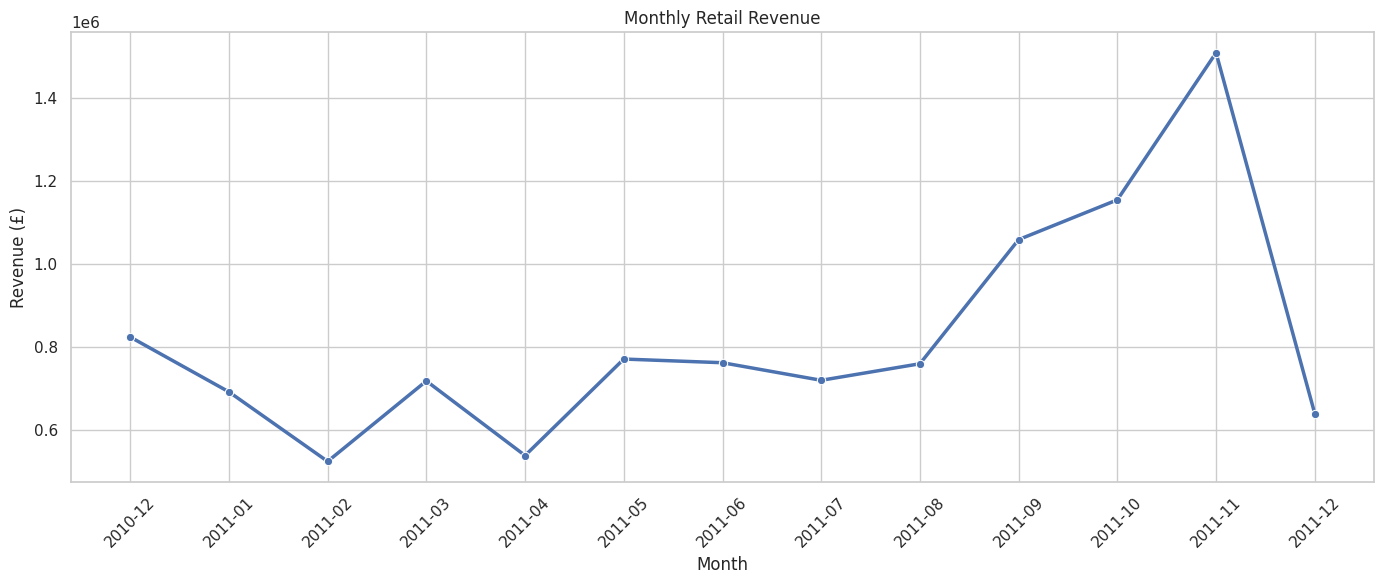

,YearMonth,Revenue,Orders,Units
0,2010-12,823566.70,1559,359167
1,2011-01,691267.81,1086,387752
2,2011-02,523598.44,1100,283546
3,2011-03,717562.07,1454,377475
4,2011-04,537775.55,1246,308794
5,2011-05,770456.37,1681,395699
6,2011-06,761582.81,1533,389150
7,2011-07,719191.25,1475,401739
8,2011-08,759115.18,1361,421758
9,2011-09,1058506.60,1837,570764


In [42]:
monthly_sales = (
    sales.groupby("YearMonth", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .sort_values("YearMonth")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="Revenue",
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Retail Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales

December 2011 contains only part of the month,

3.4 Sales by day of the week

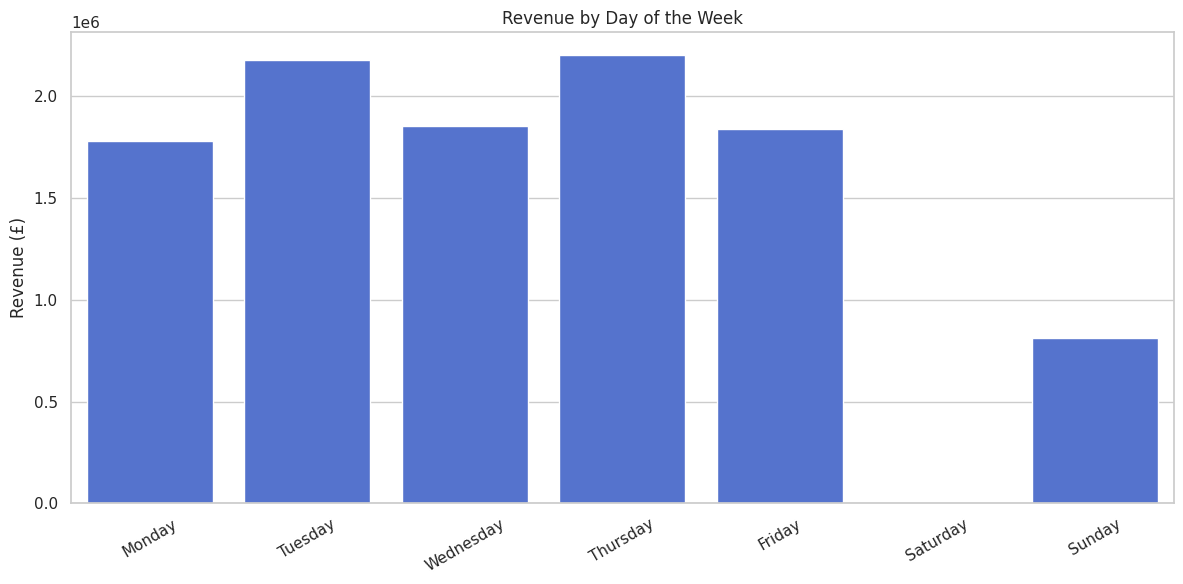

In [43]:
 day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_sales = (
    sales.groupby("DayName", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

daily_sales["DayName"] = pd.Categorical(
    daily_sales["DayName"],
    categories=day_order,
    ordered=True
)

daily_sales = daily_sales.sort_values("DayName")

sns.barplot(
    data=daily_sales,
    x="DayName",
    y="Revenue",
    color="royalblue"
)

plt.title("Revenue by Day of the Week")
plt.xlabel("")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

3.5 Sales by hour

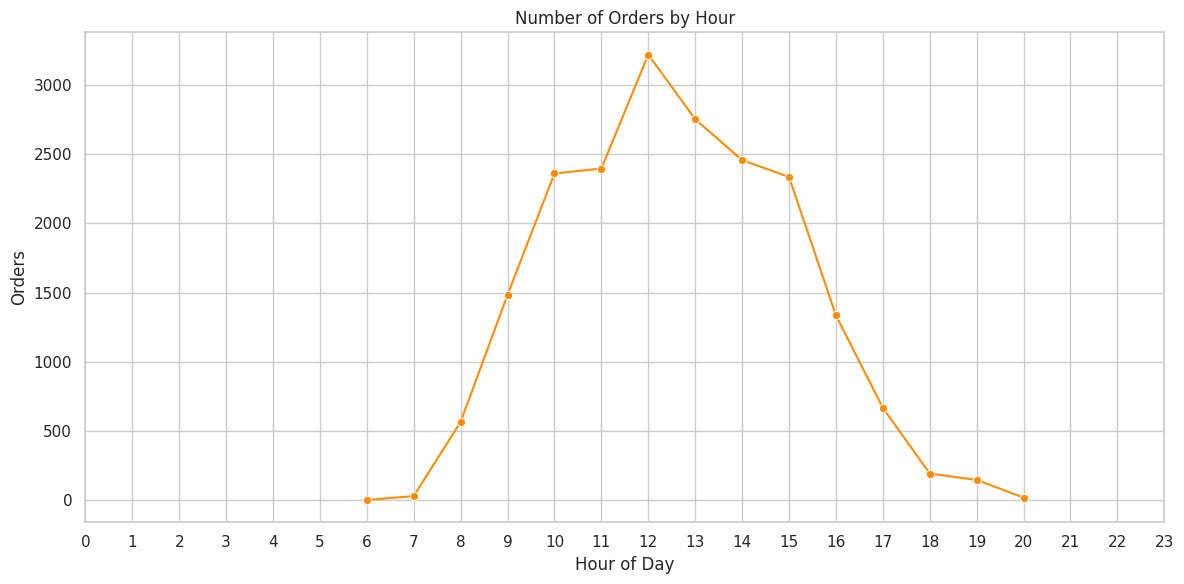

In [44]:
hourly_sales = (
    sales.groupby("Hour", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

sns.lineplot(
    data=hourly_sales,
    x="Hour",
    y="Orders",
    marker="o",
    color="darkorange"
)

plt.title("Number of Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Orders")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

3.6 Top-selling products

Exclude service and non-product codes from the product ranking:

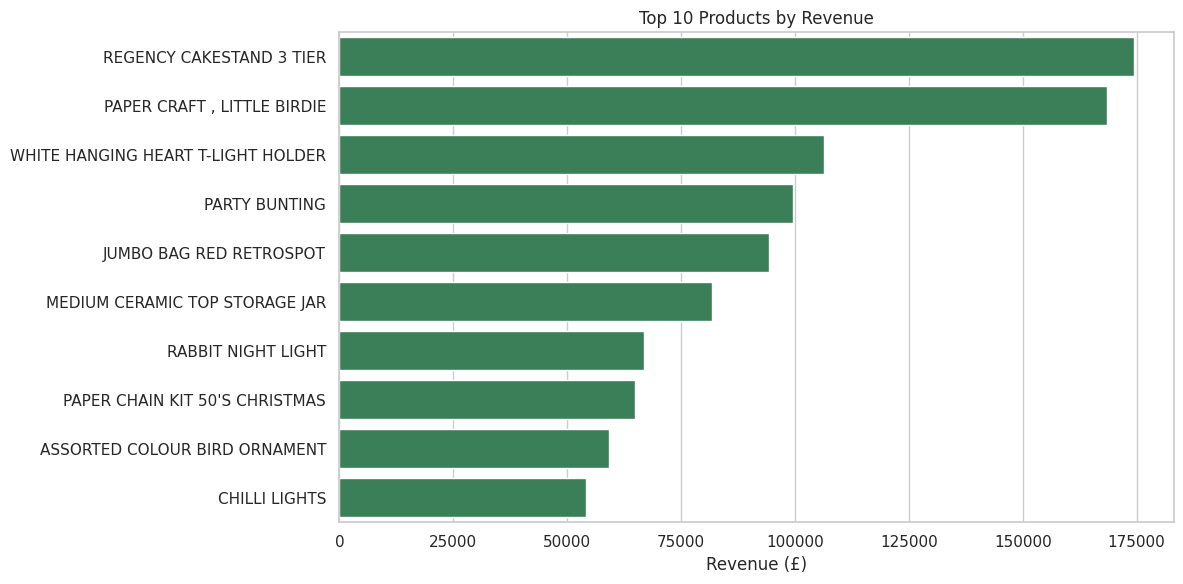

,Description,Revenue,UnitsSold,Orders
2838,REGENCY CAKESTAND 3 TIER,174484.74,13879,1988
2375,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3828,WHITE HANGING HEART T-LIGHT HOLDER,106289.82,37890,2256
2400,PARTY BUNTING,99504.33,18295,1685
1802,JUMBO BAG RED RETROSPOT,94340.05,48474,2089
2038,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
2725,RABBIT NIGHT LIGHT,66956.67,30784,994
2369,PAPER CHAIN KIT 50'S CHRISTMAS,64946.39,19353,1160
216,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455
735,CHILLI LIGHTS,54117.76,10306,661


In [28]:
non_product_codes = [
    "POST", "DOT", "M", "D", "S",
    "AMAZONFEE", "BANK CHARGES", "CRUK"
]

product_data = sales[
    ~sales["StockCode"].isin(non_product_codes)
].copy()

top_products = (
    product_data.groupby("Description", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

sns.barplot(
    data=top_products,
    y="Description",
    x="Revenue",
    color="seagreen"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")
plt.tight_layout()
plt.show()

top_products

3.7 Country performance

In [29]:
country_sales = (
    sales.groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_sales.head(10)

,Country,Revenue,Orders,Customers
36,United Kingdom,9023469.96,18021,3920
24,Netherlands,285446.34,94,9
10,EIRE,283453.96,288,3
14,Germany,228867.14,457,94
13,France,209715.11,392,87
0,Australia,138521.31,57,9
31,Spain,61577.11,90,30
33,Switzerland,57089.90,54,21
3,Belgium,41196.34,98,25
32,Sweden,38378.33,36,8


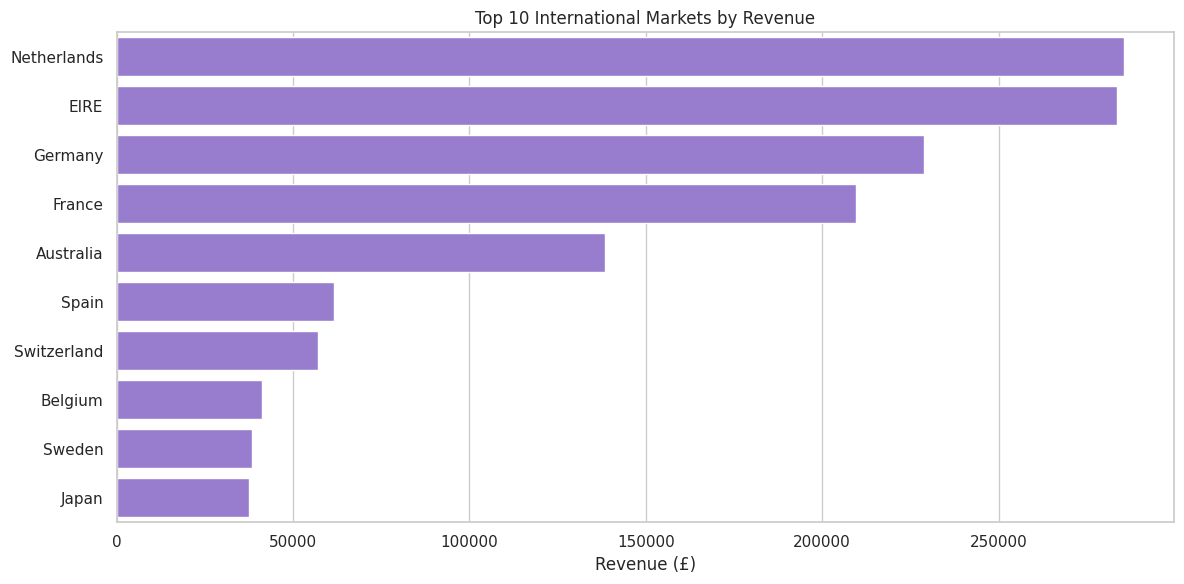

In [30]:
international_sales = (
    country_sales[country_sales["Country"] != "United Kingdom"]
    .head(10)
)

sns.barplot(
    data=international_sales,
    y="Country",
    x="Revenue",
    color="mediumpurple"
)

plt.title("Top 10 International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")
plt.tight_layout()
plt.show()

3.8 Analyse returns and cancellations

In [31]:
returns["ReturnValue"] = (
    returns["Quantity"].abs() *
    returns["UnitPrice"].abs()
)

return_summary = pd.DataFrame({
    "Metric": [
        "Return/cancellation rows",
        "Affected invoices",
        "Estimated return value"
    ],
    "Value": [
        len(returns),
        returns["InvoiceNo"].nunique(),
        f"£{returns['ReturnValue'].sum():,.2f}"
    ]
})

return_summary

,Metric,Value
0,Return/cancellation rows,10624
1,Affected invoices,5172
2,Estimated return value,"£896,812.49"


Find the most frequently returned products:

In [32]:
top_returns = (
    returns.dropna(subset=["Description"])
    .groupby("Description", as_index=False)
    .agg(
        ReturnedUnits=("Quantity", lambda x: x.abs().sum()),
        ReturnTransactions=("InvoiceNo", "nunique")
    )
    .sort_values("ReturnedUnits", ascending=False)
    .head(10)
)

top_returns

,Description,ReturnedUnits,ReturnTransactions
1217,"PAPER CRAFT , LITTLE BIRDIE",80995,1
1052,MEDIUM CERAMIC TOP STORAGE JAR,74494,10
2062,printing smudges/thrown away,19200,2
1841,"Unsaleable, destroyed.",15644,9
2023,check,13247,120
62,?,9496,41
1494,ROTATING SILVER ANGELS T-LIGHT HLDR,9376,4
1352,Printing smudges/thrown away,9058,1
555,Damaged,7540,14
2086,throw away,5368,1


In [45]:
sales_net = sales[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "Revenue"]
].copy()

returns_net = returns[
    (returns["Quantity"] < 0) &
    (returns["UnitPrice"] > 0)
][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].copy()

returns_net["Revenue"] = (
    returns_net["Quantity"] * returns_net["UnitPrice"]
)

returns_net = returns_net.drop(columns="UnitPrice")

all_product_activity = pd.concat(
    [sales_net, returns_net],
    ignore_index=True
)

net_products = (
    all_product_activity
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        NetRevenue=("Revenue", "sum"),
        NetUnits=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .query("NetRevenue > 0 and NetUnits > 0")
    .sort_values("NetRevenue", ascending=False)
    .head(10)
)

net_products

,StockCode,Description,NetRevenue,NetUnits,Transactions
4163,DOT,DOTCOM POSTAGE,206245.48,705,707
1343,22423,REGENCY CAKESTAND 3 TIER,164762.19,13022,2168
2879,47566,PARTY BUNTING,98302.98,18018,1705
3651,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97713.04,35020,2231
3630,85099B,JUMBO BAG RED RETROSPOT,92356.03,47359,2132
2029,23084,RABBIT NIGHT LIGHT,66748.27,30676,1009
4166,POST,POSTAGE,66230.64,3003,1250
1025,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63786.04,18900,1170
3421,84879,ASSORTED COLOUR BIRD ORNAMENT,58959.73,36381,1467
3062,79321,CHILLI LIGHTS,53768.06,10226,667
